In [5]:
# Cell 1 — imports

import json
import time
import urllib.request
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd

In [6]:
# Cell 2 — season list and URLs
SEASONS = {
    37: "2004/2005", 38: "2005/2006", 39: "2006/2007", 40: "2007/2008",
    41: "2008/2009", 21: "2009/2010", 22: "2010/2011", 23: "2011/2012",
    24: "2012/2013", 25: "2013/2014", 26: "2014/2015", 27: "2015/2016",
    2: "2016/2017", 1: "2017/2018", 4: "2018/2019", 42: "2019/2020",
    90: "2020/2021",
}

MATCHES_URL = "https://raw.githubusercontent.com/statsbomb/open-data/master/data/matches/11/{}.json"
EVENTS_URL = "https://raw.githubusercontent.com/statsbomb/open-data/master/data/events/{}.json"

In [7]:
print(SEASONS)
print(MATCHES_URL)

{37: '2004/2005', 38: '2005/2006', 39: '2006/2007', 40: '2007/2008', 41: '2008/2009', 21: '2009/2010', 22: '2010/2011', 23: '2011/2012', 24: '2012/2013', 25: '2013/2014', 26: '2014/2015', 27: '2015/2016', 2: '2016/2017', 1: '2017/2018', 4: '2018/2019', 42: '2019/2020', 90: '2020/2021'}
https://raw.githubusercontent.com/statsbomb/open-data/master/data/matches/11/{}.json


In [8]:
# Cell 3 — helper function
def fetch_json(url, timeout=20):
    with urllib.request.urlopen(url, timeout=timeout) as r:
        return json.load(r)

In [10]:
# Cell 4 — Step 1: get every Barcelona match_id per season

season_matches = {}  # season_id -> {"season_name":..., "match_ids":[...]}
for sid, name in SEASONS.items():
    data = fetch_json(MATCHES_URL.format(sid))
    barca_ids = [
        m["match_id"] for m in data
        if m["home_team"]["home_team_name"] == "Barcelona"
        or m["away_team"]["away_team_name"] == "Barcelona"
    ]
    season_matches[sid] = {"season_name": name, "match_ids": barca_ids}
    print(f"{name}: {len(barca_ids)} matches")

2004/2005: 7 matches
2005/2006: 17 matches
2006/2007: 26 matches
2007/2008: 27 matches
2008/2009: 31 matches
2009/2010: 35 matches
2010/2011: 33 matches
2011/2012: 37 matches
2012/2013: 32 matches
2013/2014: 31 matches
2014/2015: 38 matches
2015/2016: 38 matches
2016/2017: 34 matches
2017/2018: 36 matches
2018/2019: 34 matches
2019/2020: 33 matches
2020/2021: 35 matches


In [11]:
# Cell 5 — Step 2: extraction function
def extract_messi_locations(match_id, season_name, retries=3):
    url = EVENTS_URL.format(match_id)
    events = None
    for attempt in range(retries):
        try:
            events = fetch_json(url, timeout=40)
            break
        except Exception as e:
            if attempt == retries - 1:
                print(f"  match {match_id} failed after {retries} tries: {e}")
                return []
            time.sleep(2)  # brief pause before retry

    rows = []
    for e in events:
        player = e.get("player", {})
        if not player or "Messi" not in player.get("name", ""):
            continue
        loc = e.get("location")
        if not loc:
            continue
        rows.append({
            "season": season_name,
            "x": loc[0],
            "y": loc[1],
            "event_type": e.get("type", {}).get("name"),
            "minute": e.get("minute"),
            "match_id": match_id,
        })
    return rows

In [12]:
# Cell 6 — Step 2: run the download (this is the slow one, a few minutes)
all_rows = []
jobs = []
with ThreadPoolExecutor(max_workers=6) as pool:
    for sid, info in season_matches.items():
        for mid in info["match_ids"]:
            jobs.append(pool.submit(extract_messi_locations, mid, info["season_name"]))

    done = 0
    failed = 0
    for fut in as_completed(jobs):
        result = fut.result()
        if not result:
            failed += 1
        all_rows.extend(result)
        done += 1
        if done % 50 == 0:
            print(f"{done}/{len(jobs)} matches processed... ({failed} failed so far)")

print(f"\nTotal Messi located events: {len(all_rows)}")
print(f"Matches that failed completely: {failed}")

50/524 matches processed... (0 failed so far)
100/524 matches processed... (0 failed so far)
150/524 matches processed... (0 failed so far)
200/524 matches processed... (0 failed so far)
250/524 matches processed... (0 failed so far)
300/524 matches processed... (0 failed so far)
350/524 matches processed... (5 failed so far)
400/524 matches processed... (5 failed so far)
450/524 matches processed... (5 failed so far)
500/524 matches processed... (5 failed so far)

Total Messi located events: 114833
Matches that failed completely: 5


In [13]:
# Cell 7 — save CSV + a proper Excel summary workbook python
import pandas as pd

df = pd.DataFrame(all_rows)

# Make sure x/y are numeric (sometimes location can be 2 or 3 values; keep first two)
df["x"] = pd.to_numeric(df["x"])
df["y"] = pd.to_numeric(df["y"])

# Order seasons chronologically instead of alphabetically
season_order = [
    "2004/2005","2005/2006","2006/2007","2007/2008","2008/2009",
    "2009/2010","2010/2011","2011/2012","2012/2013","2013/2014",
    "2014/2015","2015/2016","2016/2017","2017/2018","2018/2019",
    "2019/2020","2020/2021",
]
df["season"] = pd.Categorical(df["season"], categories=season_order, ordered=True)
df = df.sort_values(["season", "match_id", "minute"])

# Save raw CSV as before
df.to_csv("../data/messi_locations_by_season.csv", index=False)

# Build a summary table: events per season + event-type breakdown
season_counts = df.groupby("season", observed=True).size().rename("total_events")
event_type_pivot = df.pivot_table(
    index="season", columns="event_type", values="x", aggfunc="count", observed=True
).fillna(0).astype(int)

summary = pd.concat([season_counts, event_type_pivot], axis=1)

# Write a multi-sheet Excel file: raw data + summary
with pd.ExcelWriter("../data/messi_heatmap_data.xlsx", engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="raw_locations", index=False)
    summary.to_excel(writer, sheet_name="season_summary")

print("Saved CSV and Excel workbook to ../data/")
summary

Saved CSV and Excel workbook to ../data/


,total_events,50/50,Ball Receipt*,Ball Recovery,Block,Carry,Clearance,Dispossessed,Dribble,Dribbled Past,...,Error,Foul Committed,Foul Won,Interception,Miscontrol,Offside,Own Goal For,Pass,Pressure,Shot
season,,,,,,,,,,,,,,,,,,,,,
2004/2005,179,0,52,4,1,45,0,2,7,3,...,0,1,5,0,3,0,0,31,13,6
2005/2006,2097,1,570,79,16,546,0,38,103,16,...,0,19,49,5,30,0,0,360,196,38
2006/2007,4655,2,1362,92,20,1257,2,91,227,19,...,0,39,82,8,45,2,0,939,350,63
2007/2008,4789,2,1356,107,23,1344,1,88,264,23,...,0,36,107,14,39,1,0,982,300,65
2008/2009,6405,0,1940,165,38,1735,1,102,272,24,...,0,28,100,12,58,3,0,1447,309,111
2009/2010,7392,2,2194,154,32,2075,1,107,344,32,...,0,32,127,18,58,0,0,1642,356,161
2010/2011,9129,2,2864,153,33,2580,0,106,357,15,...,1,24,94,7,65,0,0,2323,309,146
2011/2012,9930,2,3177,158,25,2777,1,108,373,23,...,0,31,107,11,72,0,1,2492,329,198
2012/2013,7398,4,2435,99,28,2017,1,79,252,20,...,0,15,111,10,64,1,1,1827,245,158


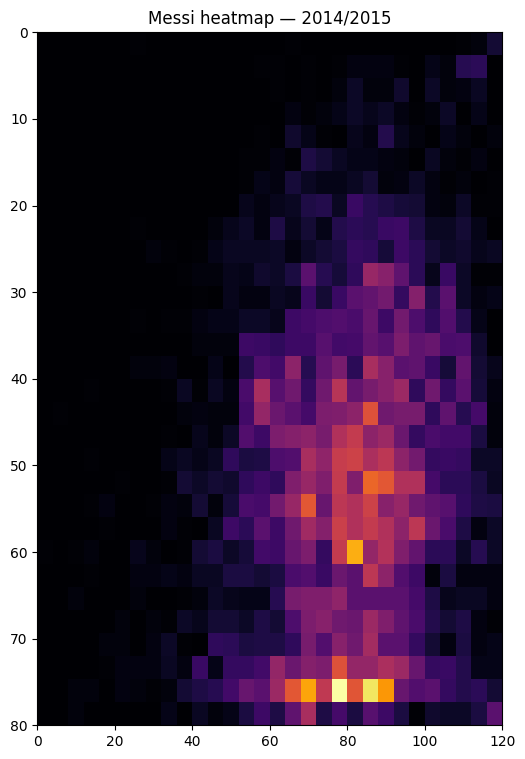

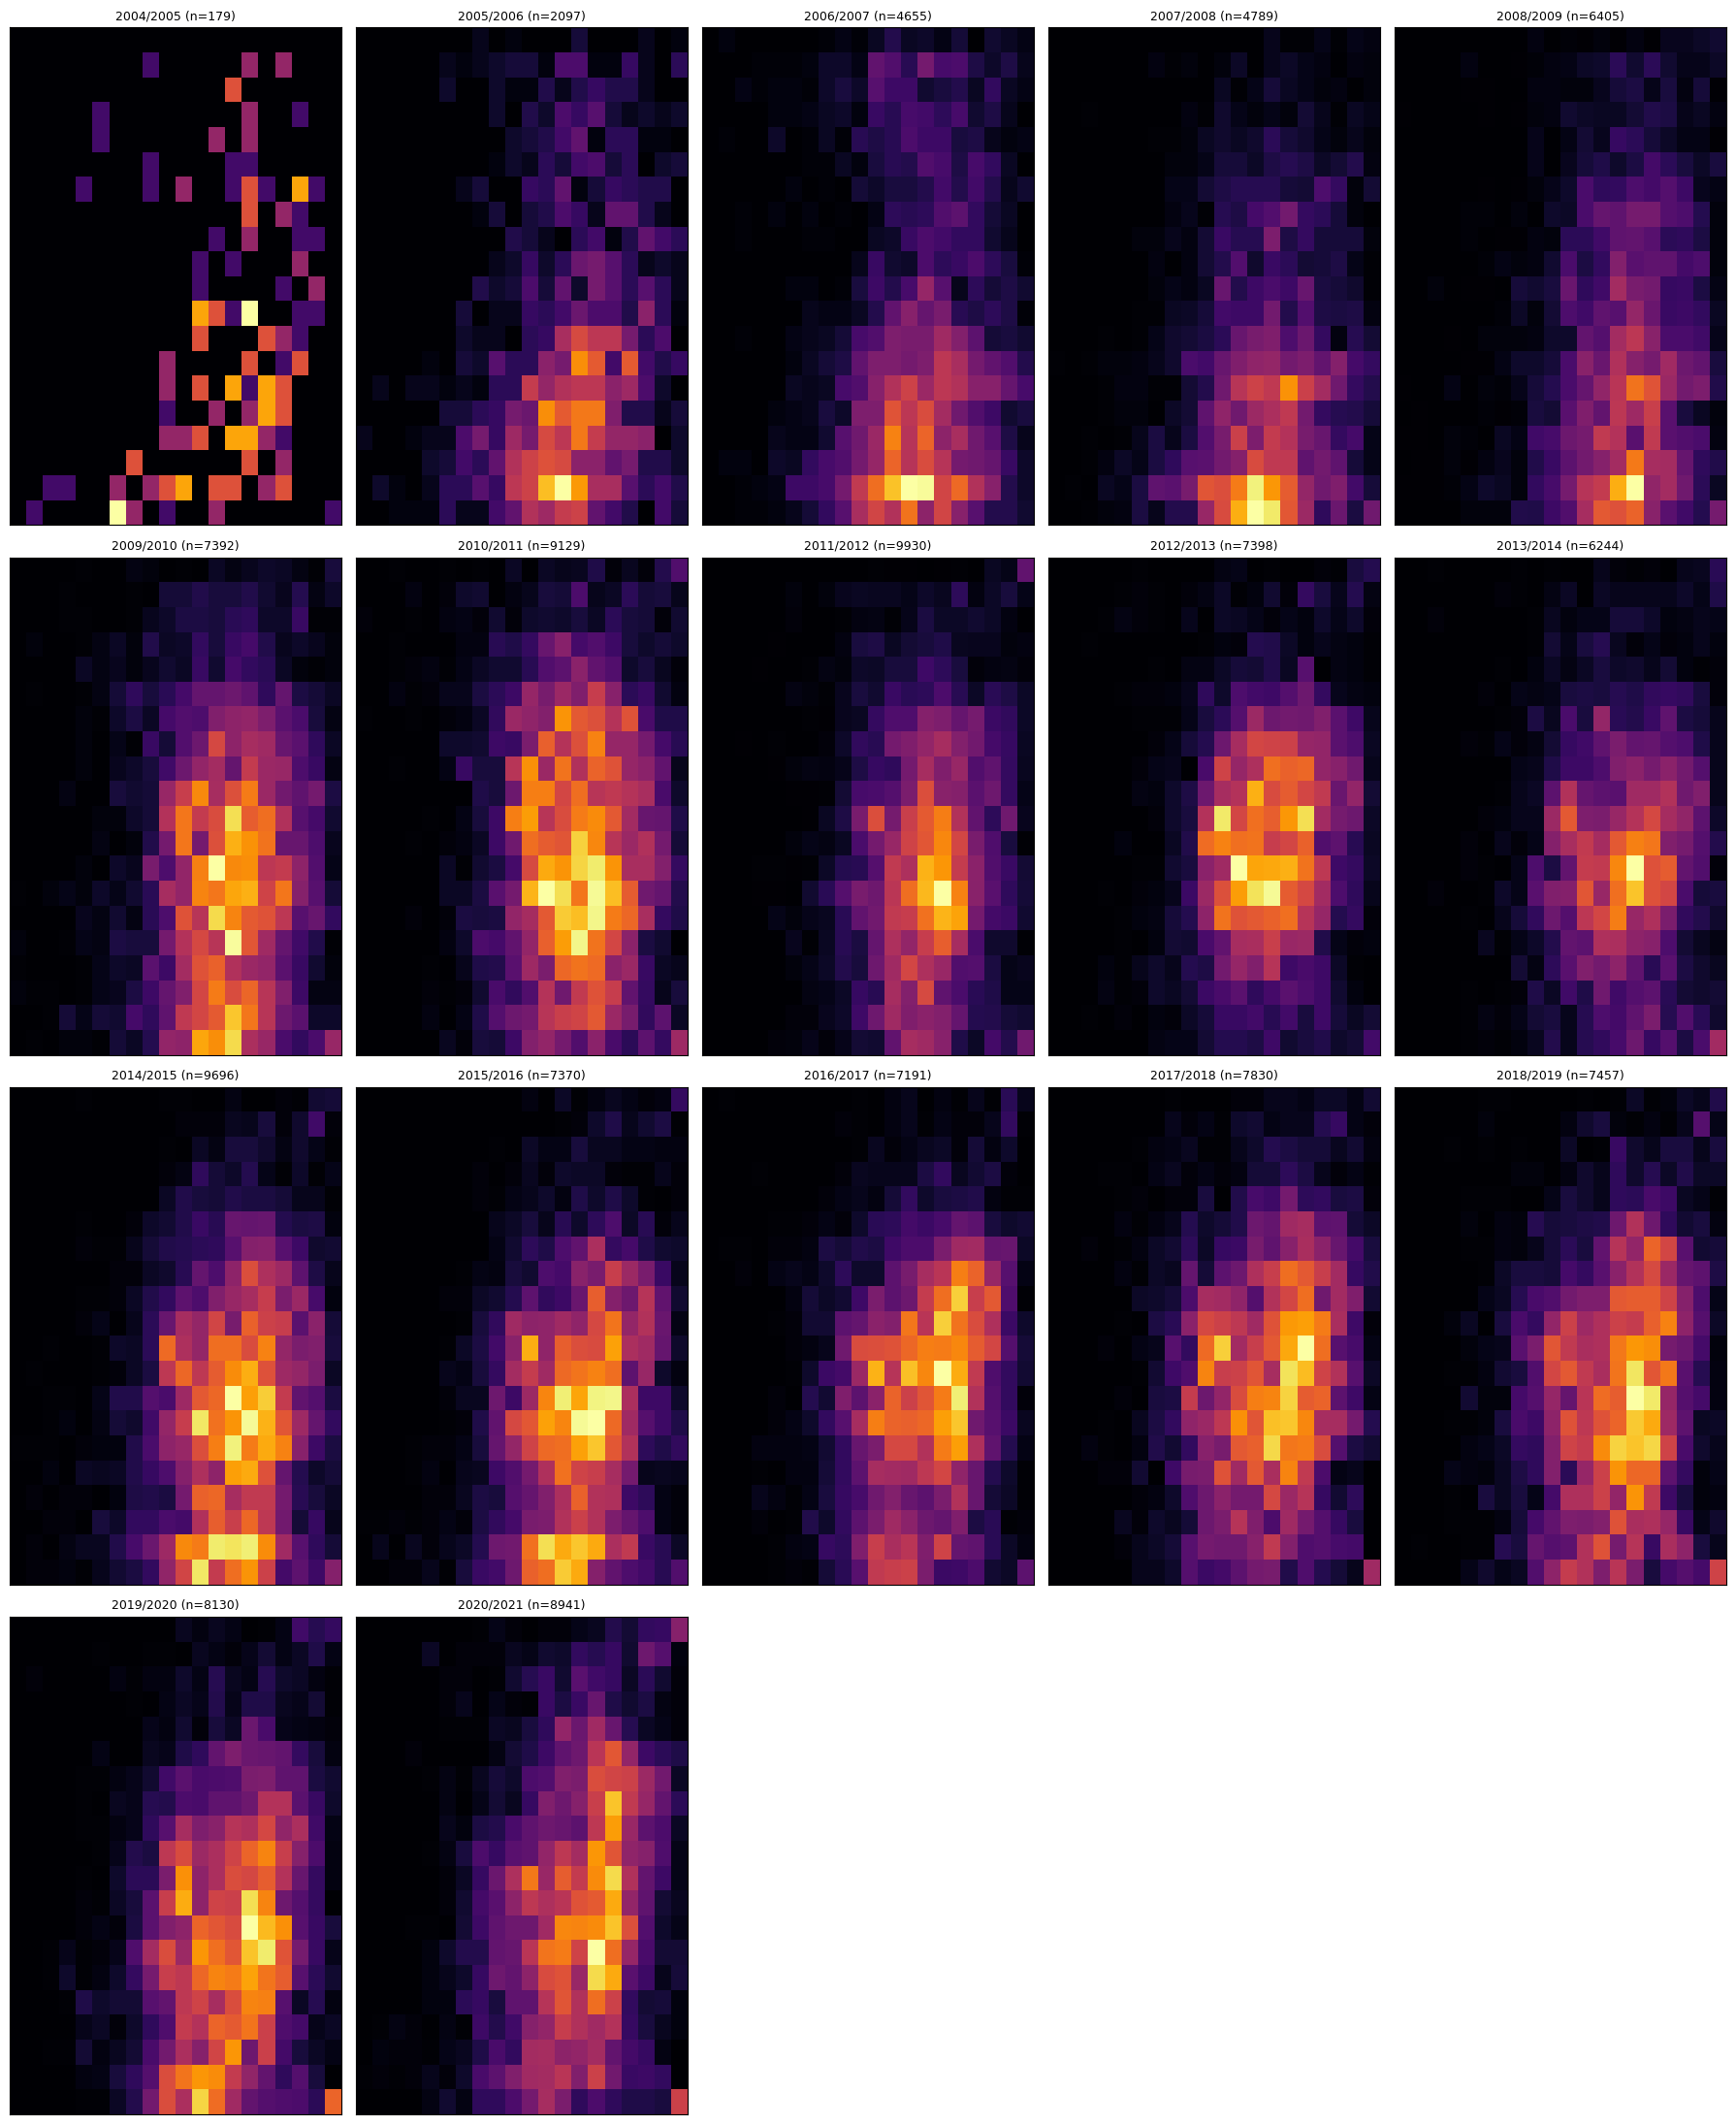

In [14]:
# Cell 8 — sanity-check plot, plus a quick multi-season grid so you can eyeball everything at once
import matplotlib.pyplot as plt

# Single season check
season_to_plot = "2014/2015"
sub = df[df["season"] == season_to_plot]

plt.figure(figsize=(6, 9))
plt.hist2d(sub["x"], sub["y"], bins=30, range=[[0, 120], [0, 80]], cmap="inferno")
plt.gca().invert_yaxis()
plt.title(f"Messi heatmap — {season_to_plot}")
plt.show()

# Grid of all seasons so you can spot anything weird (e.g. near-empty seasons)
fig, axes = plt.subplots(4, 5, figsize=(18, 22))
for ax, season in zip(axes.flat, season_order):
    s = df[df["season"] == season]
    if len(s) > 0:
        ax.hist2d(s["x"], s["y"], bins=20, range=[[0, 120], [0, 80]], cmap="inferno")
    ax.invert_yaxis()
    ax.set_title(f"{season} (n={len(s)})", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
for ax in axes.flat[len(season_order):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [19]:
# Cell 9 — imports for animation
import numpy as np
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import LinearSegmentedColormap

In [20]:
# Cell 10 — build smooth density grid per season
GRID_X, GRID_Y = 140, 100  # resolution of the smooth field
xi = np.linspace(0, 120, GRID_X)
yi = np.linspace(0, 80, GRID_Y)
XX, YY = np.meshgrid(xi, yi)

def season_density(season_name, sigma=3.0):
    sub = df[df["season"] == season_name]
    pts = np.vstack([sub["x"], sub["y"]])
    # 2D histogram first (kde on 100k+ points is slow), then smooth -> looks identical to KDE, much faster
    hist, _, _ = np.histogram2d(sub["x"], sub["y"], bins=[GRID_X, GRID_Y], range=[[0,120],[0,80]])
    hist = hist.T  # match meshgrid orientation
    smooth = gaussian_filter(hist, sigma=sigma)
    smooth = smooth / smooth.max()  # normalize 0-1
    return smooth

season_grids = {s: season_density(s) for s in season_order}
print("Built smooth density grids for", len(season_grids), "seasons")

Built smooth density grids for 17 seasons


In [16]:
# Cell 11 — pitch drawing + colormap setup
def draw_pitch(ax):
    """Draw a vertical full pitch (StatsBomb 120x80 coords, plotted as 80 wide x 120 tall)."""
    ax.set_facecolor("black")
    line_color = "#9a9a9a"
    lw = 1.2

    # Outer boundary (pitch is 120 long x 80 wide; we plot width on x, length on y)
    ax.plot([0,80,80,0,0],[0,0,120,120,0], color=line_color, lw=lw)
    # Halfway line
    ax.plot([0,80],[60,60], color=line_color, lw=lw)
    # Center circle
    circle = plt.Circle((40,60), 9.15, color=line_color, fill=False, lw=lw)
    ax.add_patch(circle)
    ax.plot([40],[60], marker='o', color=line_color, markersize=2)

    # Bottom penalty box + 6-yard box + arc (defensive end, y=0)
    ax.plot([18,62,62,18,18],[0,0,18,18,0], color=line_color, lw=lw)
    ax.plot([30,50,50,30,30],[0,0,6,6,0], color=line_color, lw=lw)

    # Top penalty box + 6-yard box (attacking end, y=120)
    ax.plot([18,62,62,18,18],[120,120,102,102,120], color=line_color, lw=lw)
    ax.plot([30,50,50,30,30],[120,120,114,114,120], color=line_color, lw=lw)

    ax.set_xlim(-2, 82)
    ax.set_ylim(-2, 122)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

heat_cmap = "inferno"  # already matches: black -> purple -> red -> orange -> yellow

In [21]:
# Cell 12 — interpolated frames between seasons for smooth morphin
season_grids_list = [season_grids[s] for s in season_order]

FRAMES_PER_TRANSITION = 12  # higher = smoother/slower morph between years

def interpolate_grids(grid_a, grid_b, steps):
    return [grid_a * (1 - t) + grid_b * t for t in np.linspace(0, 1, steps, endpoint=False)]

all_frames = []
frame_labels = []
for i in range(len(season_grids_list) - 1):
    interp = interpolate_grids(season_grids_list[i], season_grids_list[i+1], FRAMES_PER_TRANSITION)
    all_frames.extend(interp)
    # label each interpolated frame with the blended "year" for the slider position
    year_a, year_b = int(season_order[i][:4]), int(season_order[i+1][:4])
    frame_labels.extend(np.linspace(year_a, year_b, FRAMES_PER_TRANSITION, endpoint=False))

all_frames.append(season_grids_list[-1])
frame_labels.append(int(season_order[-1][:4]))

print(f"Total animation frames: {len(all_frames)}")

Total animation frames: 193


Saved ../output/messi_heatmap.gif


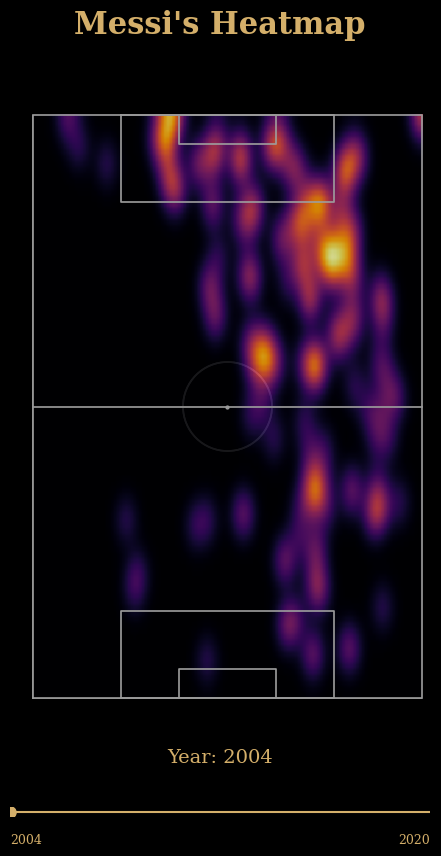

In [24]:
# Cell 13 — build and save the animation as MP4
fig, ax = plt.subplots(figsize=(6, 9), facecolor="black")
ax.set_facecolor("black")
fig.subplots_adjust(top=0.85, bottom=0.18)

draw_pitch(ax)
im = ax.imshow(all_frames[0], extent=[0,80,0,120], origin='lower', cmap=heat_cmap, alpha=0.85, zorder=2)
draw_pitch(ax)  # redraw lines on top of heat

title_text = fig.text(0.5, 0.93, "Messi's Heatmap", ha='center', color='#d4af6a',
                       fontsize=22, fontfamily='serif', fontweight='bold')
year_text = fig.text(0.5, 0.12, "Year: 2004", ha='center', color='#d4af6a',
                      fontsize=14, fontfamily='serif')

YEAR_MIN, YEAR_MAX = int(season_order[0][:4]), int(season_order[-1][:4])
slider_ax = fig.add_axes([0.15, 0.06, 0.7, 0.01])
slider_ax.set_xlim(YEAR_MIN, YEAR_MAX)
slider_ax.set_ylim(0,1)
slider_ax.axis('off')
slider_line, = slider_ax.plot([YEAR_MIN, YEAR_MAX], [0.5, 0.5], color='#d4af6a', lw=1.5)
slider_dot, = slider_ax.plot([YEAR_MIN], [0.5], marker='o', color='#d4af6a', markersize=8)
fig.text(0.15, 0.03, str(YEAR_MIN), color='#d4af6a', fontsize=9, fontfamily='serif', ha='left')
fig.text(0.85, 0.03, str(YEAR_MAX), color='#d4af6a', fontsize=9, fontfamily='serif', ha='right')

def update(frame_idx):
    im.set_data(all_frames[frame_idx])
    yr = frame_labels[frame_idx]
    year_text.set_text(f"Year: {int(yr)}")
    slider_dot.set_xdata([yr])
    return im, year_text, slider_dot

ani = animation.FuncAnimation(fig, update, frames=len(all_frames), interval=60, blit=False)

# Requires ffmpeg installed. If you get an error, run: conda install -c conda-forge ffmpeg
# ani.save("../output/messi_heatmap.mp4", writer="ffmpeg", fps=20, dpi=150,
#           savefig_kwargs={"facecolor": "black"})
# print("Saved ../output/messi_heatmap.mp4")
ani.save("../output/messi_heatmap.gif", writer="pillow", fps=20, dpi=120,
          savefig_kwargs={"facecolor": "black"})
print("Saved ../output/messi_heatmap.gif")